# Output BAB 4.4.1 — Hasil Implementasi Arsitektur Model

Notebook ini khusus membuat artefak untuk subbab **4.4.1 Hasil Implementasi Arsitektur Model** sesuai `TODO_BAB_4_Lengkap.md` dan `TODO_BAB_4_Checklist_Output.md`. Output mencakup tabel spesifikasi U-Net dan ProCANet, verifikasi forward pass, diagram arsitektur aktual, narasi output logit, dan checklist cakupan TODO.


## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.4.1 Spesifikasi Implementasi Arsitektur

Membuat tabel komponen U-Net dan ProCANet berdasarkan implementasi `training/models/`.


In [3]:
model_specs = pd.DataFrame([
    {"komponen": "Jenis model", "U-Net": "Single encoder-decoder", "ProCANet": "Dual encoder-decoder dengan Progressive Cross-Attention"},
    {"komponen": "Input utama", "U-Net": "7 channel: VV, VH, Hue, Saturation, Value, Slope, HAND", "ProCANet": "Encoder 1: 7 channel penuh; Encoder 2: VV, VH"},
    {"komponen": "Output akhir", "U-Net": "1 channel logit", "ProCANet": "1 channel logit"},
    {"komponen": "Base channels", "U-Net": "32", "ProCANet": "32"},
    {"komponen": "Kedalaman encoder", "U-Net": "4 level", "ProCANet": "4 level pada masing-masing encoder"},
    {"komponen": "Channel encoder", "U-Net": "32, 64, 128, 256", "ProCANet": "32, 64, 128, 256 pada Encoder 1 dan Encoder 2"},
    {"komponen": "Bottleneck", "U-Net": "ConvBlock 256 -> 512", "ProCANet": "ConvBlock 256 -> 512 pada tiap encoder, lalu PCAB bottleneck"},
    {"komponen": "Blok konvolusi", "U-Net": "Conv2d 3x3 + GroupNorm + ReLU, dua kali", "ProCANet": "Conv2d 3x3 + GroupNorm + ReLU, dua kali"},
    {"komponen": "Downsampling", "U-Net": "MaxPool2d 2x2 pada setiap level encoder", "ProCANet": "MaxPool2d 2x2 pada kedua encoder"},
    {"komponen": "Upsampling/decoder", "U-Net": "ConvTranspose2d 2x2 + ConvBlock", "ProCANet": "ConvTranspose2d 2x2 + ConvBlock memakai fused skips"},
    {"komponen": "Mekanisme fusi", "U-Net": "Fusi langsung 7-channel sejak input dan skip connection encoder-decoder", "ProCANet": "ProgressiveCrossAttentionBlock pada skip features dan bottleneck"},
    {"komponen": "File implementasi", "U-Net": "training/models/unet.py + blocks.py", "ProCANet": "training/models/procanet.py + blocks.py"},
])
save_table(model_specs, "4_4_1_model_architecture_specs.csv")

source_checks = pd.DataFrame([
    {"file": "training/models/unet.py", "exists": (ROOT / "training/models/unet.py").exists(), "role": "U-Net implementation"},
    {"file": "training/models/procanet.py", "exists": (ROOT / "training/models/procanet.py").exists(), "role": "ProCANet implementation"},
    {"file": "training/models/blocks.py", "exists": (ROOT / "training/models/blocks.py").exists(), "role": "ConvBlock, Encoder, Decoder shared blocks"},
    {"file": "tests/test_models.py", "exists": (ROOT / "tests/test_models.py").exists(), "role": "Model forward-pass tests"},
])
save_table(source_checks, "4_4_1_model_source_files.csv")


saved table: outputs/bab4/tables/4_4_1_model_architecture_specs.csv (12 rows)


,komponen,U-Net,ProCANet
0,Jenis model,Single encoder-decoder,Dual encoder-decoder dengan Progressive Cross-...
1,Input utama,"7 channel: VV, VH, Hue, Saturation, Value, Slo...","Encoder 1: 7 channel penuh; Encoder 2: VV, VH"
2,Output akhir,1 channel logit,1 channel logit
3,Base channels,32,32
4,Kedalaman encoder,4 level,4 level pada masing-masing encoder
5,Channel encoder,"32, 64, 128, 256","32, 64, 128, 256 pada Encoder 1 dan Encoder 2"
6,Bottleneck,ConvBlock 256 -> 512,"ConvBlock 256 -> 512 pada tiap encoder, lalu P..."
7,Blok konvolusi,"Conv2d 3x3 + GroupNorm + ReLU, dua kali","Conv2d 3x3 + GroupNorm + ReLU, dua kali"
8,Downsampling,MaxPool2d 2x2 pada setiap level encoder,MaxPool2d 2x2 pada kedua encoder
9,Upsampling/decoder,ConvTranspose2d 2x2 + ConvBlock,ConvTranspose2d 2x2 + ConvBlock memakai fused ...


saved table: outputs/bab4/tables/4_4_1_model_source_files.csv (4 rows)


,file,exists,role
0,training/models/unet.py,True,U-Net implementation
1,training/models/procanet.py,True,ProCANet implementation
2,training/models/blocks.py,True,"ConvBlock, Encoder, Decoder shared blocks"
3,tests/test_models.py,True,Model forward-pass tests


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_1_model_source_files.csv')

## 4.4.1 Verifikasi Forward Pass

Menjalankan forward pass dummy untuk memastikan kontrak input-output model sesuai dataset tile.


In [4]:
forward_rows = []
try:
    import torch
    from training.models import UNet, ProCANet, ProgressiveCrossAttentionBlock
    torch.set_grad_enabled(False)
    device = torch.device("cpu")
    configs = [
        ("U-Net", UNet(in_channels=7, out_channels=1, base_channels=32).to(device).eval(), (torch.zeros(1, 7, 128, 128),), "Batch x 7 x H x W"),
        ("ProCANet", ProCANet(encoder1_channels=7, encoder2_channels=2, out_channels=1, base_channels=32).to(device).eval(), ({"encoder1": torch.zeros(1, 7, 128, 128), "encoder2": torch.zeros(1, 2, 128, 128)},), "Encoder1 Batch x 7 x H x W; Encoder2 Batch x 2 x H x W"),
    ]
    for model_name, model, inputs, input_contract in configs:
        try:
            out = model(*inputs)
            params = sum(p.numel() for p in model.parameters())
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            forward_rows.append({
                "model": model_name,
                "input_contract": input_contract,
                "input_shapes": "; ".join(str({k: tuple(v.shape) for k, v in x.items()}) if isinstance(x, dict) else str(tuple(x.shape)) for x in inputs),
                "output_shape": str(tuple(out.shape)),
                "expected_output": "Batch x 1 x H x W",
                "output_type": "logit, belum sigmoid/threshold",
                "parameter_count": params,
                "trainable_parameter_count": trainable,
                "status": "ok" if tuple(out.shape) == (1, 1, 128, 128) else "shape_mismatch",
            })
        except Exception as exc:
            forward_rows.append({"model": model_name, "input_contract": input_contract, "status": "forward_error", "note": f"{type(exc).__name__}: {exc}"})
    block = ProgressiveCrossAttentionBlock(channels=32).eval()
    a = torch.zeros(1, 32, 64, 64)
    b = torch.zeros(1, 32, 64, 64)
    fused = block(a, b)
    forward_rows.append({
        "model": "ProgressiveCrossAttentionBlock",
        "input_contract": "dua tensor skip/bottleneck dengan channel sama",
        "input_shapes": f"{tuple(a.shape)}; {tuple(b.shape)}",
        "output_shape": str(tuple(fused.shape)),
        "expected_output": "shape sama dengan input feature",
        "output_type": "fused feature",
        "parameter_count": sum(p.numel() for p in block.parameters()),
        "trainable_parameter_count": sum(p.numel() for p in block.parameters() if p.requires_grad),
        "status": "ok" if tuple(fused.shape) == tuple(a.shape) else "shape_mismatch",
    })
except Exception as exc:
    forward_rows.append({"model": "all", "status": "import_error", "note": f"{type(exc).__name__}: {exc}"})
forward_pass = pd.DataFrame(forward_rows)
save_table(forward_pass, "4_4_1_forward_pass_verification.csv")


saved table: outputs/bab4/tables/4_4_1_forward_pass_verification.csv (3 rows)


,model,input_contract,input_shapes,output_shape,expected_output,output_type,parameter_count,trainable_parameter_count,status
0,U-Net,Batch x 7 x H x W,"(1, 7, 128, 128)","(1, 1, 128, 128)",Batch x 1 x H x W,"logit, belum sigmoid/threshold",7764193,7764193,ok
1,ProCANet,Encoder1 Batch x 7 x H x W; Encoder2 Batch x 2...,"{'encoder1': (1, 7, 128, 128), 'encoder2': (1,...","(1, 1, 128, 128)",Batch x 1 x H x W,"logit, belum sigmoid/threshold",25052705,25052705,ok
2,ProgressiveCrossAttentionBlock,dua tensor skip/bottleneck dengan channel sama,"(1, 32, 64, 64); (1, 32, 64, 64)","(1, 32, 64, 64)",shape sama dengan input feature,fused feature,36992,36992,ok


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_1_forward_pass_verification.csv')

## 4.4.1 Diagram Arsitektur Aktual

Membuat diagram U-Net dan ProCANet berdasarkan struktur kode repo, bukan diagram teori umum.


saved figure: outputs/bab4/figures/4_4_1_unet_architecture_diagram.png


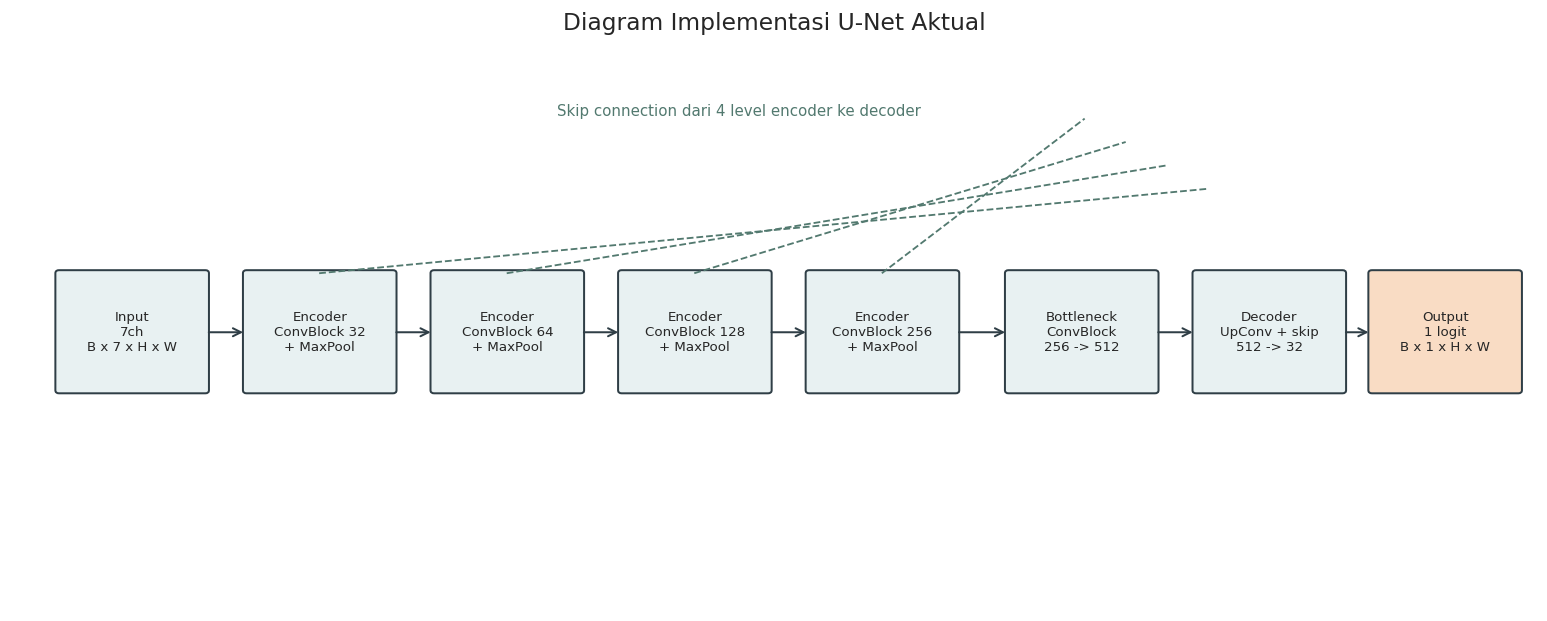

saved figure: outputs/bab4/figures/4_4_1_procanet_architecture_diagram.png


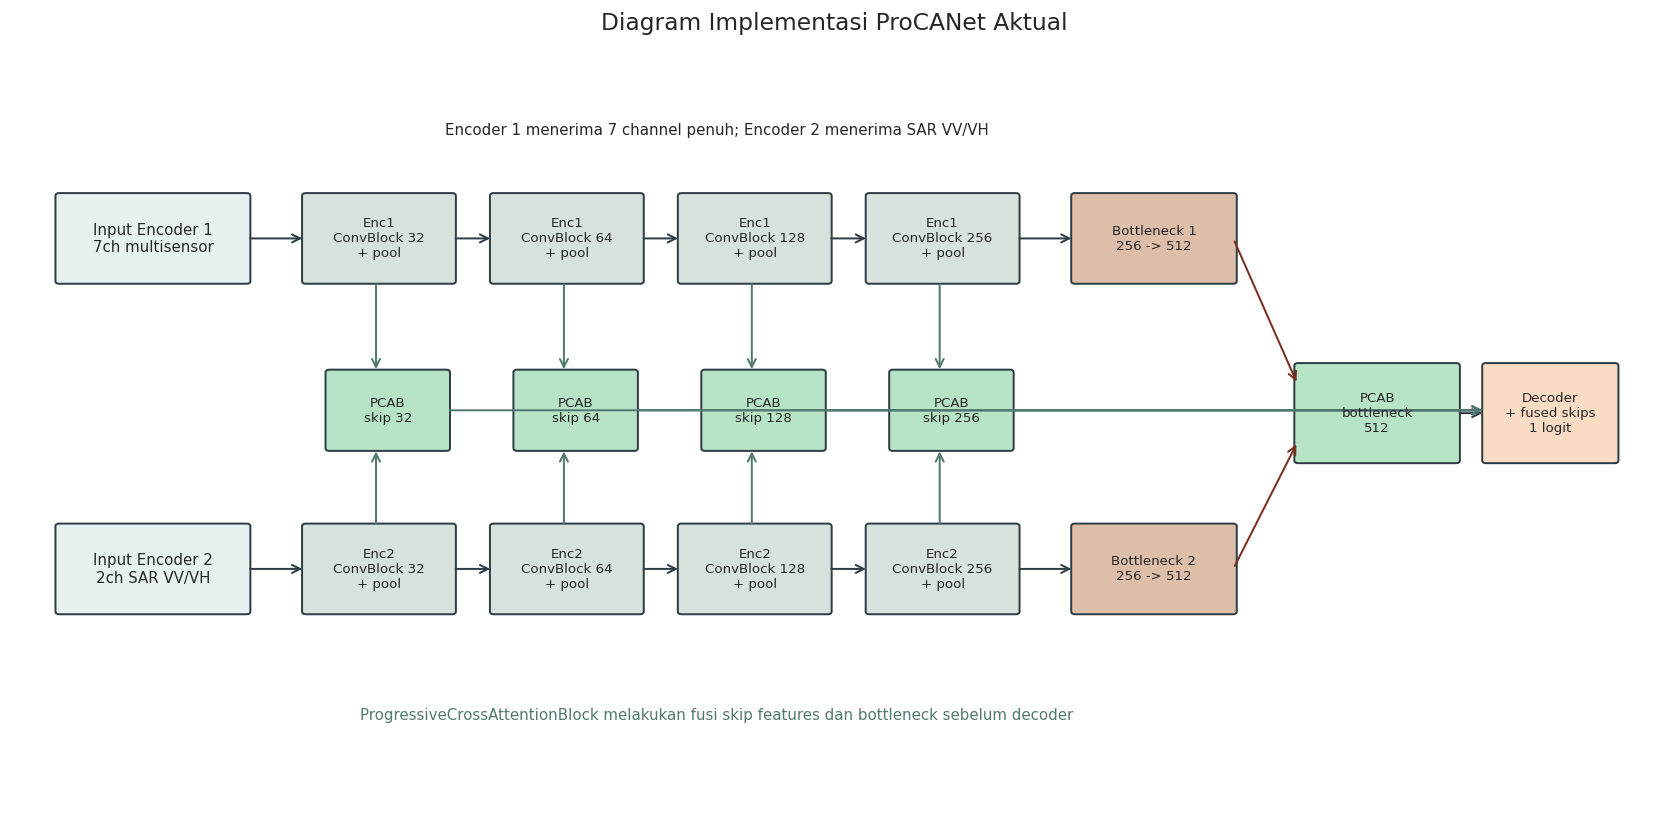

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_4_1_procanet_architecture_diagram.png')

In [5]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, width, height, text, facecolor="#E8F1F2", edgecolor="#2F3E46", fontsize=9):
    box = FancyBboxPatch(xy, width, height, boxstyle="round,pad=0.03,rounding_size=0.03", facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2)
    ax.add_patch(box)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, text, ha="center", va="center", fontsize=fontsize)
    return box

def arrow(ax, start, end, color="#2F3E46"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=12, linewidth=1.2, color=color))

# U-Net actual implementation diagram.
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.5)
ax.axis("off")
ax.set_title("Diagram Implementasi U-Net Aktual", fontsize=14, pad=12)

x_positions = [0.4, 2.0, 3.6, 5.2, 6.8, 8.5, 10.1, 11.6]
labels = [
    "Input\n7ch\nB x 7 x H x W",
    "Encoder\nConvBlock 32\n+ MaxPool",
    "Encoder\nConvBlock 64\n+ MaxPool",
    "Encoder\nConvBlock 128\n+ MaxPool",
    "Encoder\nConvBlock 256\n+ MaxPool",
    "Bottleneck\nConvBlock\n256 -> 512",
    "Decoder\nUpConv + skip\n512 -> 32",
    "Output\n1 logit\nB x 1 x H x W",
]
for x, label in zip(x_positions, labels):
    add_box(ax, (x, 2.15), 1.25, 1.15, label, facecolor="#E8F1F2" if "Output" not in label else "#F9DCC4", fontsize=8)
for x1, x2 in zip(x_positions[:-1], x_positions[1:]):
    arrow(ax, (x1 + 1.25, 2.72), (x2, 2.72))
for idx, x in enumerate(x_positions[1:5], start=1):
    ax.plot([x + 0.62, 10.55 - idx * 0.35], [3.3, 3.9 + idx * 0.23], color="#52796F", linewidth=1.1, linestyle="--")
ax.text(6.2, 4.85, "Skip connection dari 4 level encoder ke decoder", ha="center", fontsize=9, color="#52796F")
save_fig(fig, "4_4_1_unet_architecture_diagram.png")

# ProCANet actual implementation diagram.
fig, ax = plt.subplots(figsize=(14, 7.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("Diagram Implementasi ProCANet Aktual", fontsize=14, pad=12)

add_box(ax, (0.4, 5.55), 1.6, 0.9, "Input Encoder 1\n7ch multisensor", "#E8F1F2")
add_box(ax, (0.4, 2.05), 1.6, 0.9, "Input Encoder 2\n2ch SAR VV/VH", "#E8F1F2")
encoder_x = [2.5, 4.1, 5.7, 7.3]
channels = [32, 64, 128, 256]
for row_y, prefix in [(5.55, "Enc1"), (2.05, "Enc2")]:
    for x, ch in zip(encoder_x, channels):
        add_box(ax, (x, row_y), 1.25, 0.9, f"{prefix}\nConvBlock {ch}\n+ pool", "#D8E2DC", fontsize=8)
for x1, x2 in zip([0.4] + encoder_x[:-1], encoder_x):
    arrow(ax, (x1 + (1.6 if x1 == 0.4 else 1.25), 6.0), (x2, 6.0))
    arrow(ax, (x1 + (1.6 if x1 == 0.4 else 1.25), 2.5), (x2, 2.5))

pcab_x = [2.7, 4.3, 5.9, 7.5]
for x, ch in zip(pcab_x, channels):
    add_box(ax, (x, 3.78), 1.0, 0.8, f"PCAB\nskip {ch}", "#B7E4C7", fontsize=8)
    arrow(ax, (x + 0.4, 5.55), (x + 0.4, 4.58), "#52796F")
    arrow(ax, (x + 0.4, 2.95), (x + 0.4, 3.78), "#52796F")

add_box(ax, (9.05, 5.55), 1.35, 0.9, "Bottleneck 1\n256 -> 512", "#DDBEA9", fontsize=8)
add_box(ax, (9.05, 2.05), 1.35, 0.9, "Bottleneck 2\n256 -> 512", "#DDBEA9", fontsize=8)
add_box(ax, (10.95, 3.65), 1.35, 1.0, "PCAB\nbottleneck\n512", "#B7E4C7", fontsize=8)
add_box(ax, (12.55, 3.65), 1.1, 1.0, "Decoder\n+ fused skips\n1 logit", "#F9DCC4", fontsize=8)
arrow(ax, (8.55, 6.0), (9.05, 6.0))
arrow(ax, (8.55, 2.5), (9.05, 2.5))
arrow(ax, (10.4, 6.0), (10.95, 4.45), "#7A2E1F")
arrow(ax, (10.4, 2.5), (10.95, 3.85), "#7A2E1F")
arrow(ax, (12.3, 4.15), (12.55, 4.15))
for x in pcab_x:
    arrow(ax, (x + 1.0, 4.18), (12.55, 4.18), "#52796F")
ax.text(6.0, 7.1, "Encoder 1 menerima 7 channel penuh; Encoder 2 menerima SAR VV/VH", ha="center", fontsize=9)
ax.text(6.0, 0.9, "ProgressiveCrossAttentionBlock melakukan fusi skip features dan bottleneck sebelum decoder", ha="center", fontsize=9, color="#52796F")
save_fig(fig, "4_4_1_procanet_architecture_diagram.png")


## 4.4.1 Narasi Interpretasi

Menyimpan paragraf siap pakai untuk menjelaskan fusi model, output logit, sigmoid, dan threshold inferensi.


In [6]:
interpretation_text = """# Interpretasi Implementasi Arsitektur 4.4.1

Dua model segmentasi berhasil diimplementasikan, yaitu U-Net sebagai baseline dan ProCANet sebagai model berbasis fusi attention. U-Net menerima satu tensor 7-channel berisi VV, VH, Hue, Saturation, Value, Slope, dan HAND, lalu memprosesnya melalui encoder-decoder dengan skip connection.

ProCANet memakai dua encoder paralel. Encoder 1 menerima input multisensor lengkap 7-channel, sedangkan Encoder 2 menerima kanal SAR VV/VH. Fitur dari kedua encoder digabungkan menggunakan ProgressiveCrossAttentionBlock pada setiap skip feature dan pada bottleneck sebelum diteruskan ke decoder.

Kedua model menghasilkan output berupa logit 1-channel dengan ukuran spasial yang sama dengan input. Output ini belum berupa mask biner final. Pada tahap inferensi atau evaluasi, logit perlu diproses dengan sigmoid, kemudian threshold 0,5 untuk menghasilkan prediksi banjir biner.

Hasil forward pass menunjukkan kontrak input-output sesuai dengan dataset tile: U-Net menerima Batch x 7 x H x W dan ProCANet menerima Encoder1 Batch x 7 x H x W serta Encoder2 Batch x 2 x H x W. Karena output keduanya Batch x 1 x H x W, kedua arsitektur siap dipakai untuk pelatihan dan evaluasi segmentasi biner.
"""
path = NARRATIVE_DIR / "4_4_1_architecture_interpretation.md"
path.write_text(interpretation_text, encoding="utf-8")
print(f"saved narrative: {path.relative_to(ROOT)}")
print(interpretation_text)
path


saved narrative: outputs/bab4/narratives/4_4_1_architecture_interpretation.md
# Interpretasi Implementasi Arsitektur 4.4.1

Dua model segmentasi berhasil diimplementasikan, yaitu U-Net sebagai baseline dan ProCANet sebagai model berbasis fusi attention. U-Net menerima satu tensor 7-channel berisi VV, VH, Hue, Saturation, Value, Slope, dan HAND, lalu memprosesnya melalui encoder-decoder dengan skip connection.

ProCANet memakai dua encoder paralel. Encoder 1 menerima input multisensor lengkap 7-channel, sedangkan Encoder 2 menerima kanal SAR VV/VH. Fitur dari kedua encoder digabungkan menggunakan ProgressiveCrossAttentionBlock pada setiap skip feature dan pada bottleneck sebelum diteruskan ke decoder.

Kedua model menghasilkan output berupa logit 1-channel dengan ukuran spasial yang sama dengan input. Output ini belum berupa mask biner final. Pada tahap inferensi atau evaluasi, logit perlu diproses dengan sigmoid, kemudian threshold 0,5 untuk menghasilkan prediksi banjir biner.

Hasil f

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/narratives/4_4_1_architecture_interpretation.md')

## Checklist 4.4.1

Memverifikasi artefak 4.4.1 yang diminta TODO.


In [7]:
expected = [
    ("wajib", "Tabel spesifikasi U-Net dan ProCANet", TABLE_DIR / "4_4_1_model_architecture_specs.csv"),
    ("wajib", "Tabel verifikasi forward pass", TABLE_DIR / "4_4_1_forward_pass_verification.csv"),
    ("opsional", "Diagram U-Net aktual", FIG_DIR / "4_4_1_unet_architecture_diagram.png"),
    ("sangat_disarankan", "Diagram ProCANet aktual", FIG_DIR / "4_4_1_procanet_architecture_diagram.png"),
    ("narasi_wajib", "Penjelasan output logit dan threshold inferensi", NARRATIVE_DIR / "4_4_1_architecture_interpretation.md"),
    ("disarankan", "Tabel file sumber model", TABLE_DIR / "4_4_1_model_source_files.csv"),
]
checklist_4_4_1 = pd.DataFrame([
    {"priority": p, "todo_item": item, "artifact": str(path.relative_to(ROOT)), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
    for p, item, path in expected
])
save_table(checklist_4_4_1, "4_4_1_todo_coverage_checklist.csv")
missing = checklist_4_4_1[~checklist_4_4_1["exists"]]
if missing.empty:
    print("All 4.4.1 TODO artifacts created.")
else:
    print("Missing 4.4.1 artifacts:")
    display(missing)


saved table: outputs/bab4/tables/4_4_1_todo_coverage_checklist.csv (6 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Tabel spesifikasi U-Net dan ProCANet,outputs/bab4/tables/4_4_1_model_architecture_s...,True,1070
1,wajib,Tabel verifikasi forward pass,outputs/bab4/tables/4_4_1_forward_pass_verific...,True,666
2,opsional,Diagram U-Net aktual,outputs/bab4/figures/4_4_1_unet_architecture_d...,True,160452
3,sangat_disarankan,Diagram ProCANet aktual,outputs/bab4/figures/4_4_1_procanet_architectu...,True,244853
4,narasi_wajib,Penjelasan output logit dan threshold inferensi,outputs/bab4/narratives/4_4_1_architecture_int...,True,1230
5,disarankan,Tabel file sumber model,outputs/bab4/tables/4_4_1_model_source_files.csv,True,250


All 4.4.1 TODO artifacts created.
